# Build RDF Visualization (Python 3.11)

This notebook reproduces the same tasks as `bin/create_visualization.py`: parse a Turtle graph and generate an interactive HTML visualization.

## 1) Verify environment
This notebook should run in the `python311` conda environment.

In [1]:
import os
import sys
from pathlib import Path

print('Python executable:', sys.executable)
print('Python version   :', sys.version.split()[0])
print('Conda env        :', os.environ.get('CONDA_DEFAULT_ENV', '<not set>'))

Python executable: C:\Users\maria\anaconda3\envs\python311\python.exe
Python version   : 3.11.14
Conda env        : python311


## 2) Import visualization functions from `bin/visualization_core.py`

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
bin_dir = os.path.join(project_root, 'bin')

if bin_dir not in sys.path:
    sys.path.insert(0, bin_dir)

from visualization_core import build_graph_from_ttl, create_html

print('Project root:', project_root)
print('Bin dir     :', bin_dir)

Project root: C:\Users\maria\Desktop\IUC02\iuc02\Parsing
Bin dir     : C:\Users\maria\Desktop\IUC02\iuc02\Parsing\bin


## 3) Select LIS file, convert to TTL, and configure outputs

In [3]:
import subprocess
import ipywidgets as widgets
from IPython.display import display

search_dirs = [
    os.path.join(project_root, 'Data', 'BAMDataset'),
    os.path.join(project_root, 'Data'),
]

available_dirs = [path for path in search_dirs if os.path.isdir(path)]
if not available_dirs:
    raise FileNotFoundError('No configured data directories were found.')

def list_lis_files(base_dir: str) -> list[str]:
    found = []
    for root, _, files in os.walk(base_dir):
        for file_name in files:
            if file_name.lower().endswith('.lis'):
                found.append(os.path.join(root, file_name))
    return sorted(set(found))

default_folder = next(
    (path for path in available_dirs if path.endswith(os.path.join('Data', 'BAMDataset'))),
    available_dirs[0],
)

folder_path_text = widgets.Text(
    value=default_folder,
    description='Folder:',
    layout=widgets.Layout(width='95%'),
)
browse_button = widgets.Button(description='Browse folder', button_style='info')
load_button = widgets.Button(description='Load files')

file_dropdown = widgets.Dropdown(
    options=[],
    description='LIS file:',
    layout=widgets.Layout(width='95%'),
)

ttl_output_text = widgets.Text(
    value=os.path.join(project_root, 'Notebooks', 'selected_from_lis.ttl'),
    description='TTL out:',
    layout=widgets.Layout(width='95%'),
)

output_text = widgets.Text(
    value=os.path.join(project_root, 'Notebooks', 'rdf_graph_viewer.html'),
    description='HTML out:',
    layout=widgets.Layout(width='95%'),
)

title_text = widgets.Text(
    value='IUC02 RDF Web Visualization',
    description='Title:',
    layout=widgets.Layout(width='95%'),
)

status_html = widgets.HTML()
selection_info = widgets.HTML()

def refresh_file_dropdown(*_):
    folder_path = folder_path_text.value.strip()
    if not os.path.isdir(folder_path):
        file_dropdown.options = [('(folder not found)', '')]
        file_dropdown.value = ''
        status_html.value = f"<span style='color:#b00020;'>Folder not found: {folder_path}</span>"
        return

    files_in_folder = list_lis_files(folder_path)
    if not files_in_folder:
        file_dropdown.options = [('(no .LIS files found)', '')]
        file_dropdown.value = ''
        status_html.value = f"<span style='color:#b00020;'>No .LIS files found in: {folder_path}</span>"
        return

    options = [(os.path.relpath(path, project_root), path) for path in files_in_folder]
    file_dropdown.options = options
    file_dropdown.value = files_in_folder[0]
    status_html.value = f"<span style='color:#0a7a2a;'>Loaded {len(files_in_folder)} .LIS files.</span>"

def sync_selection(*_):
    global lis_input_path, ttl_path, input_path, output_path, title
    lis_input_path = file_dropdown.value
    ttl_path = ttl_output_text.value
    input_path = ttl_path
    output_path = output_text.value
    title = title_text.value

    folder_display = folder_path_text.value.strip()
    lis_display = os.path.relpath(lis_input_path, project_root) if lis_input_path else '(none selected)'
    ttl_display = os.path.relpath(ttl_path, project_root)
    html_display = os.path.relpath(output_path, project_root)
    selection_info.value = (
        f'<b>Folder:</b> {folder_display}<br>'
        f'<b>LIS input:</b> {lis_display}<br>'
        f'<b>TTL output:</b> {ttl_display}<br>'
        f'<b>HTML output:</b> {html_display}<br>'
        f'<b>Title:</b> {title}'
    )

def browse_folder(_):
    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        selected = filedialog.askdirectory(initialdir=folder_path_text.value or project_root)
        root.destroy()

        if selected:
            folder_path_text.value = selected
            refresh_file_dropdown()
            sync_selection()
    except Exception as exc:
        status_html.value = f"<span style='color:#b00020;'>Browse dialog unavailable: {exc}</span>"

browse_button.on_click(browse_folder)
load_button.on_click(lambda _: (refresh_file_dropdown(), sync_selection()))
folder_path_text.observe(sync_selection, names='value')
file_dropdown.observe(sync_selection, names='value')
ttl_output_text.observe(sync_selection, names='value')
output_text.observe(sync_selection, names='value')
title_text.observe(sync_selection, names='value')

refresh_file_dropdown()
sync_selection()
display(
    folder_path_text,
    widgets.HBox([browse_button, load_button]),
    file_dropdown,
    ttl_output_text,
    output_text,
    title_text,
    status_html,
    selection_info,
)

Text(value='C:\\Users\\maria\\Desktop\\IUC02\\iuc02\\Parsing\\Data\\BAMDataset', description='Folder:', layout…

Dropdown(description='LIS file:', layout=Layout(width='95%'), options=(('Data\\BAMDataset\\Vh5205_C-78.LIS', '…

Text(value='C:\\Users\\maria\\Desktop\\IUC02\\iuc02\\Parsing\\Notebooks\\selected_from_lis.ttl', description='…

Text(value='C:\\Users\\maria\\Desktop\\IUC02\\iuc02\\Parsing\\Notebooks\\rdf_graph_viewer.html', description='…

Text(value='IUC02 RDF Web Visualization', description='Title:', layout=Layout(width='95%'))

HTML(value="<span style='color:#0a7a2a;'>Loaded 12 .LIS files.</span>")

HTML(value='<b>Folder:</b> C:\\Users\\maria\\Desktop\\IUC02\\iuc02\\Parsing\\Data\\BAMDataset<br><b>LIS input:…

## 4) Convert LIS to TTL (bam2shacl), then build graph and generate HTML

In [4]:
if not lis_input_path or not os.path.exists(lis_input_path):
    raise FileNotFoundError(f'LIS input file not found: {lis_input_path}')

ttl_dir = os.path.dirname(ttl_path)
if ttl_dir and not os.path.exists(ttl_dir):
    os.makedirs(ttl_dir, exist_ok=True)

bam2shacl_script = os.path.join(project_root, 'bin', 'bam2shacl.py')
cmd = [
    sys.executable,
    bam2shacl_script,
    '-i', lis_input_path,
    '-o', ttl_path,
]
result = subprocess.run(cmd, cwd=project_root, capture_output=True, text=True)

if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    raise RuntimeError('bam2shacl conversion failed')

if not os.path.exists(ttl_path):
    raise FileNotFoundError(f'Expected TTL output not found: {ttl_path}')

graph = build_graph_from_ttl(Path(ttl_path))
create_html(graph, Path(output_path), title)

print('LIS input      :', lis_input_path)
print('TTL generated  :', os.path.abspath(ttl_path))
print('HTML generated :', os.path.abspath(output_path))

LIS input      : C:\Users\maria\Desktop\IUC02\iuc02\Parsing\Data\BAMDataset\Vh5205_C-78.LIS
TTL generated  : C:\Users\maria\Desktop\IUC02\iuc02\Parsing\Notebooks\selected_from_lis.ttl
HTML generated : C:\Users\maria\Desktop\IUC02\iuc02\Parsing\Notebooks\rdf_graph_viewer.html


## 5) Preview inside the notebook

In [5]:
from pathlib import Path
from IPython.display import HTML, IFrame, display

output_file = Path(output_path).resolve()
print('Preview file:', output_file)
print('Exists      :', output_file.exists())

if not output_file.exists():
    raise FileNotFoundError(f'Visualization HTML not found: {output_file}')

display(IFrame(src=output_file.as_uri(), width='100%', height=760))

html_text = output_file.read_text(encoding='utf-8')
display(HTML(html_text))

Preview file: C:\Users\maria\Desktop\IUC02\iuc02\Parsing\Notebooks\rdf_graph_viewer.html
Exists      : True


In [6]:
from pyvis.network import Network
from IPython.display import HTML, display

inline_net = Network(
    height='760px',
    width='100%',
    directed=True,
    notebook=True,
    cdn_resources='in_line',
)
inline_net.set_options(
    """
    {
        \"layout\": {
            \"hierarchical\": {
                \"enabled\": true,
                \"direction\": \"LR\",
                \"sortMethod\": \"directed\"
            }
        },
        \"physics\": {
            \"hierarchicalRepulsion\": {
                \"nodeDistance\": 150
            },
            \"solver\": \"hierarchicalRepulsion\"
        },
        \"edges\": {
            \"smooth\": {
                \"enabled\": true,
                \"type\": \"cubicBezier\"
            }
        }
    }
    """
)

seen_nodes = set()
for subject, predicate, obj in graph:
    source = str(subject)
    target = str(obj)
    edge_label = str(predicate).split('/')[-1].split('#')[-1]

    if source not in seen_nodes:
        inline_net.add_node(source, label=source.split('/')[-1].split('#')[-1], title=source)
        seen_nodes.add(source)

    if target not in seen_nodes:
        inline_net.add_node(target, label=target.split('/')[-1].split('#')[-1], title=target)
        seen_nodes.add(target)

    inline_net.add_edge(source, target, label=edge_label, title=str(predicate), arrows='to')

inline_html = inline_net.generate_html(notebook=True)
display(HTML(inline_html))

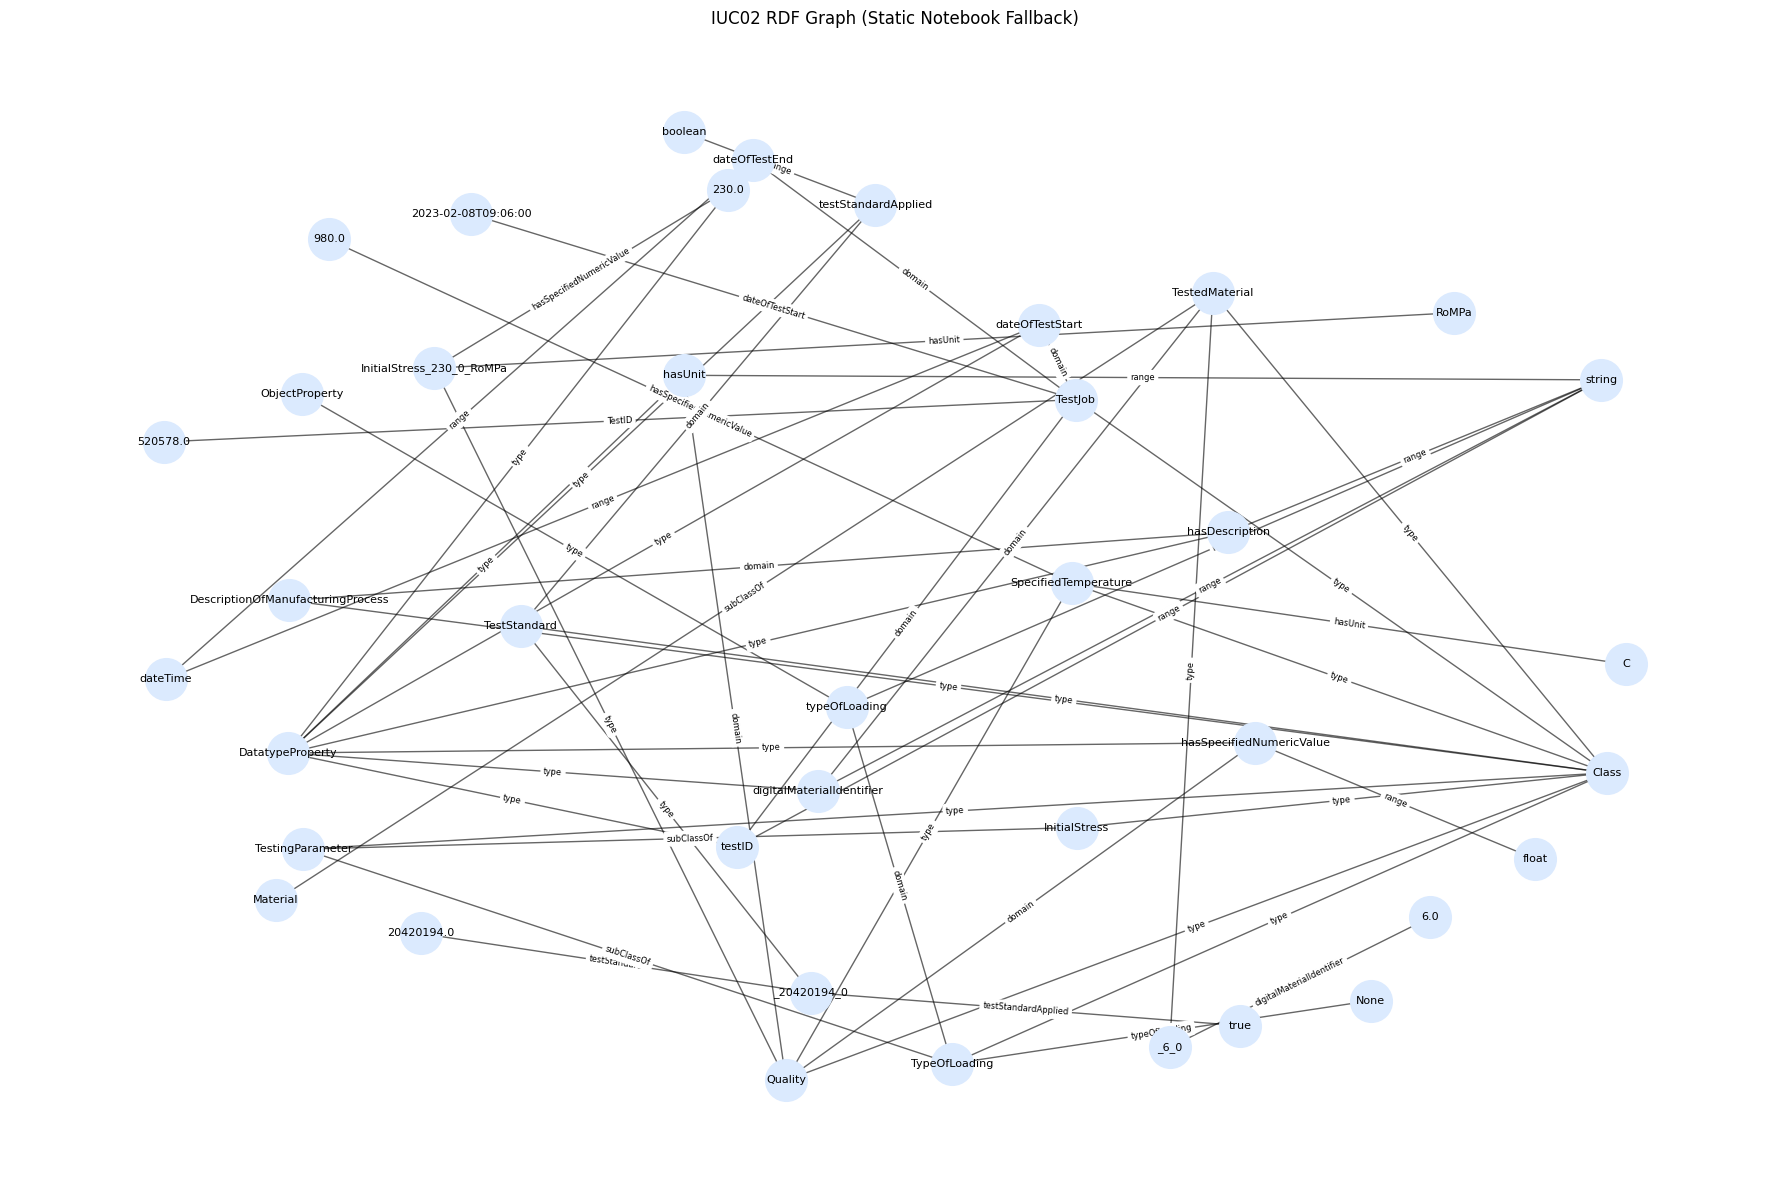

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

def short_label(value: str) -> str:
    return value.split('/')[-1].split('#')[-1]

static_graph = nx.DiGraph()
for subject, predicate, obj in graph:
    source = str(subject)
    target = str(obj)
    pred = str(predicate)
    static_graph.add_edge(source, target, label=short_label(pred))

plt.figure(figsize=(18, 12))
position = nx.spring_layout(static_graph, seed=42, k=1.4)
nx.draw_networkx_nodes(static_graph, position, node_size=900, node_color='#dbeafe')
nx.draw_networkx_edges(static_graph, position, arrows=True, alpha=0.6)
nx.draw_networkx_labels(
    static_graph,
    position,
    labels={node: short_label(node) for node in static_graph.nodes},
    font_size=8,
    font_color='black',
)
edge_labels = {(u, v): d['label'] for u, v, d in static_graph.edges(data=True)}
nx.draw_networkx_edge_labels(static_graph, position, edge_labels=edge_labels, font_size=6)
plt.title('IUC02 RDF Graph (Static Notebook Fallback)')
plt.axis('off')
plt.tight_layout()
plt.show()